In [1]:
from scipy.signal import correlate, correlation_lags
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav
import numpy as np

## Άσκηση - Εκτίμηση της θεμελιώδους συχνότητας της φωνής μας

΄Ενα πολύ σημαντικό - και ερευνητικά ενεργό - πρόβλημα στην επεξεργασία σήματος ϕωνής είναι η ακριβής εκτίμηση της θεμελιώδους συχνότητας f0 της ανθρώπινης φωνής, καθώς η θεμελιώδης συχνότητα χρησιμοποιείται σε πολλές εφαρμογές, όπως για παράδειγμα στη σύνθεση ομιλίας από κείμενο (text-to-speech synthesis). Μια απλή τέτοια μέθοδος εκτίμησης είναι η μέθοδος της αυτοσυσχέτισης, που δίνεται ως γνωστόν ως

$$ \phi_{x}(\tau) = \int_{-\infty}^{+\infty} x(t) x(t+\tau) dt $$

Ας πούμε όμως μερικές ενδιαφέρουσες λεπτομέρειες πριν περάσουμε στην άσκηση.
Η ανθρώπινη φωνή - και συγκεκριμένα, ο έμφωνος λόγος - μπορεί να παρασταθεί ως ένα σύστημα $h(t)$, που στην είσοδό του υπάρχει ενέργεια (προερχόμενη από τους πνεύμονες) σε μορφή μιας περιοδικής σειράς από παλμούς, $x(t)$, η οποία καθορίζεται από τις φωνητικές χορδές. Πληροφοριακά και μόνο, το σήμα $x(t)$ αντιπροσωπεύει την ταχύτητα ροής του αέρα ακριβώς επάνω από τις φωνητικές μας χορδές. Η είσοδος αυτή περνά σε ένα σύστημα $h(t)$, το οποίο περιγράφει τη φωνητική μας οδό, δηλ. τη θέση του στόματος, της γλώσσας, και των δοντιών, ανάλογα με το φώνημα που θέλουμε να εκφέρουμε. Το σύστημα $h(t)$ λειτουργεί σαν φίλτρο, που ενισχύει ή καταστέλλει συγκεκριμένες συχνότητες του σήματος εισόδου $x(t)$. Η έξοδος αυτού του συστήματος $y(t)$, είναι το σήμα φωνής που παράγεται, όπως φαίνεται στο σχήμα και αντιπροσωπεύει την πίεση των μορίων του αέρα ακριβώς έξω από το στόμα μας.

<p style="text-align: center"><img src="./files/sourcefilter.png" alt="sf" width="1200"/></p>

Η απόσταση μεταξύ δυο διαδοχικών παλμών της εισόδου $x(t)$ ονομάζεται **περίοδος** $T_0$ του σήματος εισόδου. Ο λόγος $f_0 = \frac{1}{T_0}$ ονομάζεται **θεμελιώδης συχνότητα** της φωνής μας, και αντιπροσωπεύει το ρυθμό με τον οποίο ανοιγοκλείνουν οι φωνητικές μας χορδές. Ένα άνοιγμα και κλείσιμο των φωνητικών χορδών αντιστοιχεί σε ένα παλμό του σήματος $x(t)$, όπως το βλέπετε στο σχήμα. Βλέπετε ότι η περιοδικότητα των φωνητικών χορδών διατηρείται και στο τελικό σήμα φωνής. Παρ' όλο που καταλαβαίνετε ότι τα σήματα δεν είναι αυστηρώς περιοδικά, μπορούμε να τα θεωρήσουμε ως τέτοια, θεωρώντας ότι συνεχίζονται επ΄ άπειρο, αλλά εμείς έχουμε ‘‘κόψει’’ ένα τμήμα τους με χρήση ενός τετραγωνικού παλμού.

Επιστρέφοντας στην άσκηση, η εκτίμηση της απόστασης $T_0$, δηλ. της περιόδου, και κατά συνέπεια της θεμελιώδους συχνότητας $f_0$, μπορεί να γίνει με πολλούς τρόπος και σε πολλούς χώρους (χρόνο, συχνότητα, άλλους). Εμείς θα χρησιμοποιήσουμε τη γνωστή μας αυτοσυσχέτιση ώστε να βρούμε ομοιότητες του σήματος της φωνής με τον εαυτό του. Οι χρονικές θέσεις ομοιότητας ϑα συμβαίνουν σε πολλαπλάσια της $T_0$, αφού ένα τμήμα περιοδικού σήματος παρουσιάζει ομοιότητες σε πολλαπλάσια της περιόδου του. Άρα η συνάρτηση αυτοσυσχέτισης περιμένουμε να παρουσιάζει τοπικά μέγιστες τιμές (δηλ. ομοιότητα) σε αυτές τις χρονικές στιγμές.
Ας δούμε πως ϑα υπολογίσουμε αυτήν την τιμή της θεμελιώδους συχνότητας.

(αʹ) Ηχογραφήστε ένα σήμα της φωνής σας όταν εκφέρετε ένα σταθερό φώνημα /α/ για περίπου τρία $(3)$ δευτερόλεπτα. Εναλλακτικά, χρησιμοποιήστε την ηχογράφησή που σας δίνεται στον κατάλογο της άσκησης αυτής.

(βʹ) Φορτώστε το σήμα στην Python με την εντολή $\texttt{s,fs = wav.read('myvoice.wav')}$

In [2]:
fs, s = wav.read("./files/alpha.wav") # αντικαταστήστε με το όνομα του αρχείου σας
s = s/np.max(np.abs(s))  # Κανονικοποίηση του σήματος

(γʹ) Κόψτε ένα τυχαίο τμήμα από τη φωνή σας, διάρκειας $40$ ms. Αυτό μπορεί να γίνει ως:

In [3]:
# Ας πάρουμε ένα τυχαίο τμήμα του σήματος s
middle = round(len(s)/2)
# Διάρκειας 40 ms
T = round(40*10**(-3)*fs)
# Το αποθηκευμένο τμήμα του σήματος s
seg = s[middle:(middle + T)]
time = np.arange(len(seg))/fs

όπου εδώ κόψαμε ένα τμήμα που ξεκινούσε από τη μέση του σήματος.

(δʹ) Τυπώστε τη γραφική παράσταση αυτού του τμήματος με χρήση της συνάρτησης plot ορίζοντας κατάλληλα τον άξονα του χρόνου. Οι γυναίκες θα έχουν περισσότερες περιόδους μέσα σε αυτά τα $40$ ms απ΄ αυτές των ανδρών. Είναι φυσιολογικό, μην ανησυχείτε. 

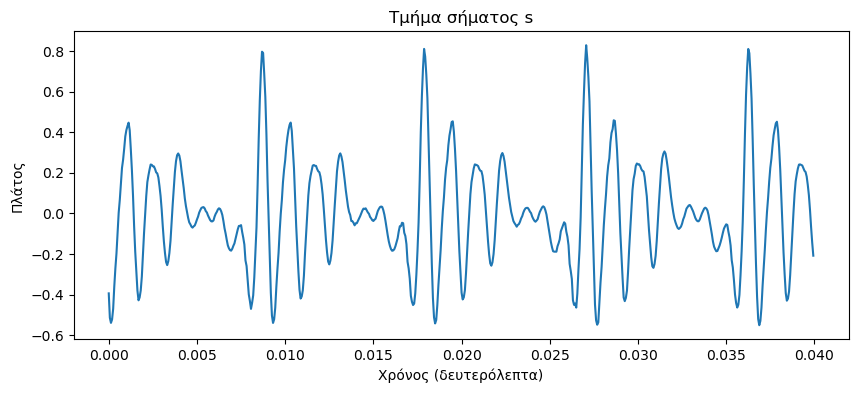

In [4]:
plt.figure(figsize=(10,4))
plt.plot(time, seg)
plt.title("Τμήμα σήματος s")
plt.xlabel('Χρόνος (δευτερόλεπτα)')
plt.ylabel('Πλάτος')
plt.show()

(εʹ) Μετρήστε με το μάτι την απόσταση μεταξύ δυο περιόδων του σήματός σας. Ένας ασφαλής τρόπος είναι να μετρήσετε την απόσταση δυο διαδοχικών μεγίστων. Για το σήμα του παραδείγματος, μπορεί κανείς να μετρήσει ότι η απόσταση είναι $T_0 = 0.00919$ s. Άρα, η θεμελιώδης συχνότητα $f_0$ είναι $f_0 = \frac{1}{T_0} = 108.8$ Hz. Ποια η θεμελιώδης συχνότητα στο δικό σας τμήμα φωνής;

(στʹ) Ας δούμε πως μπορούμε να αυτοματοποιήσουμε τη διαδικασία εύρεσης της θεμελιώδους συχνότητας. Υπολογίστε την αυτοσυσχέτιση $\phi_{x}(\tau)$ με χρήση της συνάρτησης ως

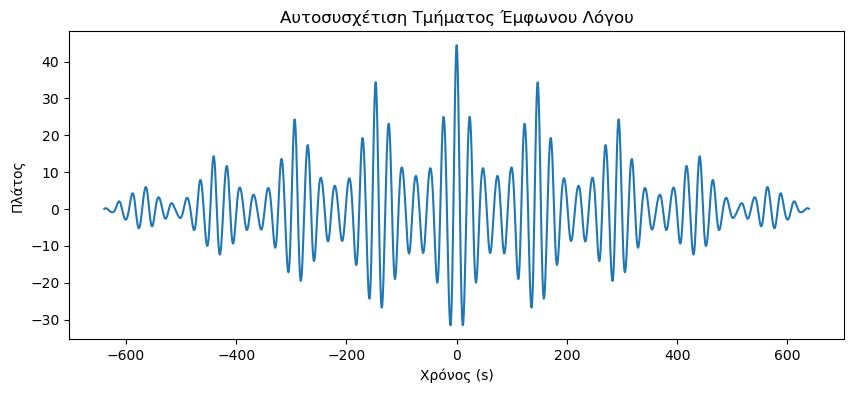

In [5]:
Dt = 1/fs
phi = correlate(seg, seg, mode="full")
t_phi = correlation_lags(len(seg), len(seg), mode="full")

plt.figure(figsize=(10,4))
plt.plot(t_phi, phi)
plt.title("Αυτοσυσχέτιση Τμήματος Έμφωνου Λόγου")
plt.xlabel("Χρόνος (s)")
plt.ylabel("Πλάτος")
plt.show()

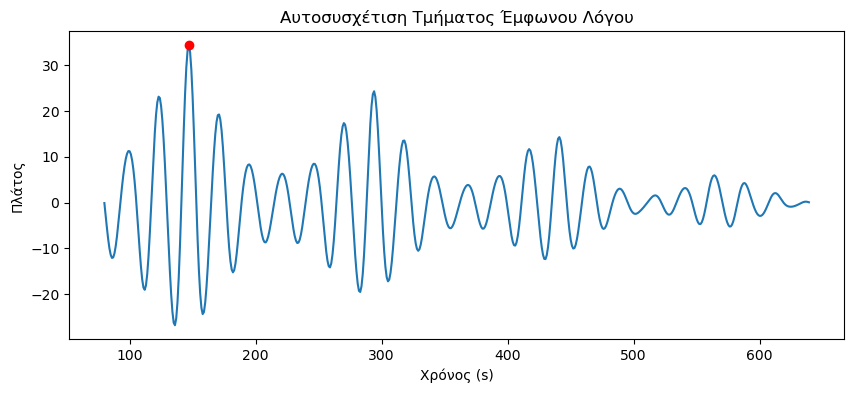

In [6]:
# Βρίσκουμε το μέγιστο peak της αυτοσυσχέτισης για θετικό χρόνο τ > 0.005 s

# Αγνοούμε κορυφές με καθυστέρηση μικρότερη από min_delay_sec
min_delay_sec = 0.005      # 5 ms, με βάση το παραπάνω σχήμα
min_lag = int(min_delay_sec * fs)

# Κρατάμε μόνο θετικές καθυστερήσεις και όχι πολύ κοντά στο μηδέν
idx1 = t_phi >= min_lag

# Βρίσκουμε τις αυτοσυσχετισεις και προσαρμόζουμε τα lags που αντιστοιχούν στις θετικές καθυστερήσεις
phi = phi[idx1]
lags = t_phi[idx1]

peak_index = np.argmax(phi)  # Βρίσκουμε τον index του μέγιστου peak

# Το τυπώνουμε επάνω στο γράφημα
plt.figure(figsize=(10,4))
plt.plot(lags, phi)
plt.plot(lags[peak_index], phi[peak_index], 'ro')  # Εμφάνιση του peak
plt.title("Αυτοσυσχέτιση Τμήματος Έμφωνου Λόγου")
plt.xlabel("Χρόνος (s)")
plt.ylabel("Πλάτος")
plt.show()

Ας το υπολογίσουμε ρητά:

In [7]:
print("Το μέγιστο peak της αυτοσυσχέτισης εμφανίζεται στο lag: {:.6f} s".format(lags[peak_index] * Dt))

Το μέγιστο peak της αυτοσυσχέτισης εμφανίζεται στο lag: 0.009187 s


In [8]:
print("Το μέγιστο peak της αυτοσυσχέτισης αντιστοιχεί σε περίοδο T0: {:.6f} Hz".format(1/(lags[peak_index] * Dt)))

Το μέγιστο peak της αυτοσυσχέτισης αντιστοιχεί σε περίοδο T0: 108.843537 Hz


(ζʹ) Παρατηρήστε στο σχήμα, ότι το πρώτο μέγιστο (πλην της τιμής $\phi_{x}(0)$, όπου ξέρετε ότι αντιπροσωπεύει την ενέργεια του σήματος) βρίσκεται τη θετική χρονική στιγμή $τ = 0.009188$ s. Αυτή η χρονική στιγμή είναι μια στιγμή μεγάλης ομοιότητας του σήματος με τον εαυτό του, άρα σίγουρα θα συμβαίνει όταν το $x(t + \tau)$ της αυτοσυσχέτισης έχει μετατοπιστεί κατά διάστημα τ διάρκειας μιας περιόδου. Αντίστοιχα, το δεύτερο μέγιστο βρίσκεται τη χρονική στιγμή $\tau = 0.01837$ s, όπου αντιστοιχεί σε μετατόπιση του $x(t + \tau)$ κατά διάστημα $τ$ δυο περιόδων, κ.ο.κ.

(ηʹ) Η θεμελιώδης συχνότητα $f_0$ με χρήση της τιμής του πρώτου μεγίστου είναι $f_0 = 1/0.009188 = 108.8$ Hz, που συμφωνεί με τη μέτρησή μας στην αρχική κυματομορφή.

(θʹ) Όμως η μέθοδος της αυτοσυσχέτισης, όπως τη δείξαμε, βασίζεται ξανά σε ‘‘χειροκίνητη’’ εύρεση του πρώτου μεγίστου, με το μάτι. Επίσης, παρατηρήστε ότι υπάρχουν κι άλλες σημαντικές κορυφές (peaks) πριν το πρώτο μέγιστο που επιλέξαμε. Πώς θα επιλέξουμε αυτόματα το σωστό peak; Γράψτε κώδικα Python που χρησιμοποιεί τη συνάρτηση $\texttt{argmax}$ της $\texttt{NumPy}$ και βρίσκει το σωστό peak της συνάρτησης αυτοσυσχέτισης, αν γνωρίζετε ότι τα όρια θεμελιωδών συχνοτήτων στους ενήλικες είναι στο διάστημα $[70, 280]$ Hz. Υπόδειγμα κώδικα δίνεται παρακάτω:

In [9]:
# Όρια συχνοτήτων σε Hz
Fr_limits = [70, 260]
# Μετατροπή σε δευτερόλεπτα
Time_limits = [1/f for f in reversed(Fr_limits)]
print(f"Όρια χρόνου = {Time_limits[0], Time_limits[1]}") # Δίνει [0.0035 0.0143]

Όρια χρόνου = (0.0038461538461538464, 0.014285714285714285)


In [10]:
# Μετατροπή σε δείγματα (samples) με βάση το fs
# Σε 1 δευτερόλεπτο έχουμε fs δείγματα, άρα σε 0.0143 δευτερόλεπτα έχουμε 0.0143*fs δείγματα
Sample_limits = [round(lim*fs) for lim in Time_limits]
print(f"Όρια δείγματος = {Sample_limits[0], Sample_limits[1]}")

Όρια δείγματος = (62, 229)


In [11]:
# Βρίσκουμε τη μέγιστη τιμή της αυτοσυσχέτισης στο διάστημα που ορίζεται από τα όρια δείγματος
phi_subset = phi[Sample_limits[0]:Sample_limits[1]]
maxind = np.argmax(phi_subset)
maxval = phi_subset[maxind]
Τ_0 = lags[Sample_limits[0] + maxind]*Dt
f0 = 1/Τ_0

print(f"Θεμελιώδης συχνότητα: F0 = {f0:.6f} Hz, Περίοδος Τ0 = {Τ_0:.6f} s") # % Δίνει f0 = 108.8435 - συμφωνούμε με τα προηγουμένα αποτελέσματα!

Θεμελιώδης συχνότητα: F0 = 108.843537 Hz, Περίοδος Τ0 = 0.009187 s


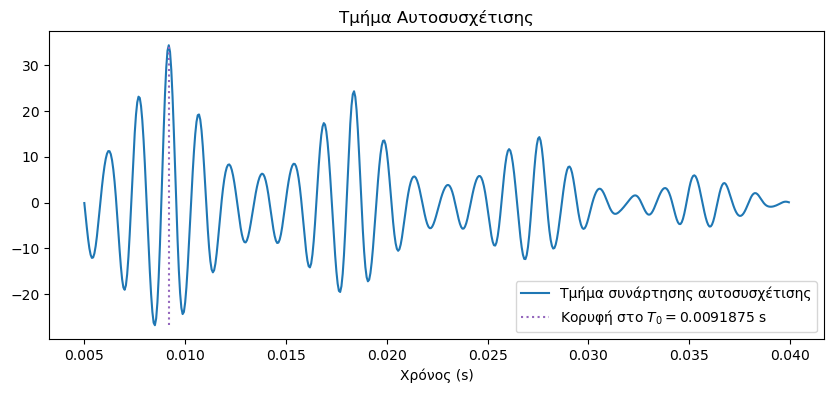

In [12]:
# Ας τα δούμε μαζί
plt.figure(figsize=(10,4))
plt.plot(lags/fs, phi, label="Τμήμα συνάρτησης αυτοσυσχέτισης")
plt.plot([Τ_0, Τ_0], [min(phi), max(phi)], linestyle=":", color=f"C{4}", label=f"Κορυφή στο $T_0= {Τ_0}$ s")
plt.title("Τμήμα Αυτοσυσχέτισης")
plt.xlabel("Χρόνος (s)")
plt.legend(loc=4)
plt.show()
plt.close()

(ιʹ) Αν οι άνδρες έχουν θεμελιώδη συχνότητα ομιλίας γύρω στο διάστημα $[70, 150]$ Hz και οι γυναίκες γύρω στο διάστημα $[180, 280]$ Hz, τότε η συχνότητα που βρήκατε εσείς ανταποκρίνεται στο σωστό διάστημα του φύλου σας;

---
---